In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv")
df.head()


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
df['segment'].value_counts()

,count
segment,
Womens E-Mail,21387
Mens E-Mail,21307
No E-Mail,21306


In [4]:
#treat no mail as 0 and mail(either men or women as 1)
df_copy=df.copy()
df_copy['treatment']=np.where(df_copy['segment']=="No E-Mail",0,1)
df_copy['outcome']=df_copy['conversion']

In [5]:
df_copy.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment,outcome
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,1,0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,1,0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1,0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,1,0


In [6]:
df_copy['treatment'].value_counts()


,count
treatment,
1,42694
0,21306


In [7]:
df_copy[['recency','history']].describe()

,recency,history
count,64000.000000,64000.000000
mean,5.763734,242.085656
std,3.507592,256.158608
min,1.000000,29.990000
25%,2.000000,64.660000
50%,6.000000,158.110000
75%,9.000000,325.657500
max,12.000000,3345.930000


In [8]:
df_copy.groupby('treatment')['outcome'].mean()

,outcome
treatment,
0,0.005726
1,0.010681


In [9]:
features=['recency','history']
df_copy.groupby('treatment')[features].mean()

,recency,history
treatment,,
0,5.749695,240.882653
1,5.770741,242.686002


In [10]:
from scipy.stats import ttest_ind
for col in features:
  t, p=ttest_ind(
      df_copy[df_copy['treatment']==1][col],
      df_copy[df_copy['treatment']==0][col],
      equal_var=False
      )
  print(col,'p-value:',round(p,4))
  #The groups are statistically similar (good! fair test) coz p>0.05 i.e under the significant region

recency p-value: 0.4738
history p-value: 0.3982


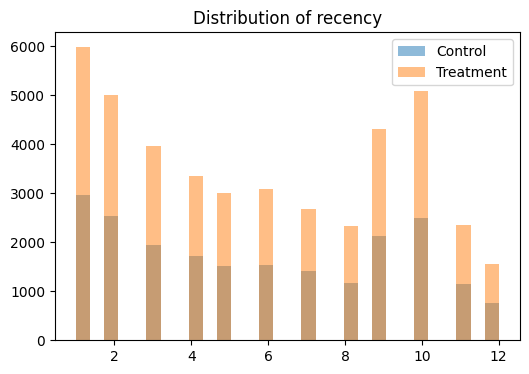

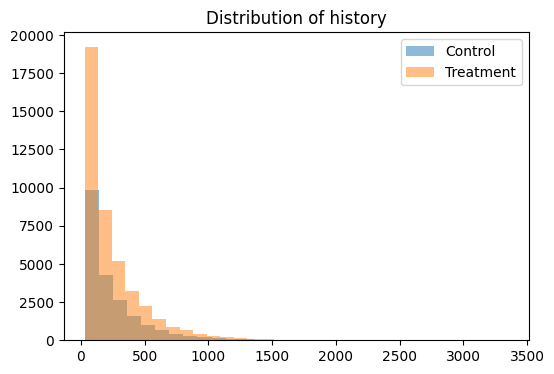

In [11]:
import matplotlib.pyplot as plt

for col in features:
    plt.figure(figsize=(6,4))
    plt.hist(df_copy[df_copy.treatment==0][col], alpha=0.5, label='Control', bins=30)
    plt.hist(df_copy[df_copy.treatment==1][col], alpha=0.5, label='Treatment', bins=30)
    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show()


In [12]:
from statsmodels.stats.proportion import proportions_ztest
count=df_copy.groupby('treatment')['outcome'].sum()
nobs=df_copy.groupby('treatment')['outcome'].count()
z,p=proportions_ztest(count,nobs)
z,p

(np.float64(-6.2437650914685685), np.float64(4.271613795144971e-10))

In [13]:
conv = df_copy.groupby('treatment')['outcome'].mean()

absolute_uplift = conv[1] - conv[0]
relative_uplift = absolute_uplift / conv[0]

absolute_uplift, relative_uplift


(np.float64(0.004954571155268468), np.float64(0.865263057656967))

In [14]:
print(conv)

treatment
0    0.005726
1    0.010681
Name: outcome, dtype: float64


In [15]:
df_copy['history_bins']=pd.qcut(
    df_copy['history'],
    q=2,
    labels=['low history','high history']

)

In [16]:
seg=df_copy.groupby(['history_bins','treatment'])['outcome'].mean().unstack()
seg

/tmp/ipython-input-3881918715.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg=df_copy.groupby(['history_bins','treatment'])['outcome'].mean().unstack()


treatment,0,1
history_bins,,
low history,0.00420,0.007893
high history,0.00727,0.013453


In [17]:
seg['uplift']=seg[1]-seg[0]
seg

treatment,0,1,uplift
history_bins,,,
low history,0.00420,0.007893,0.003693
high history,0.00727,0.013453,0.006183


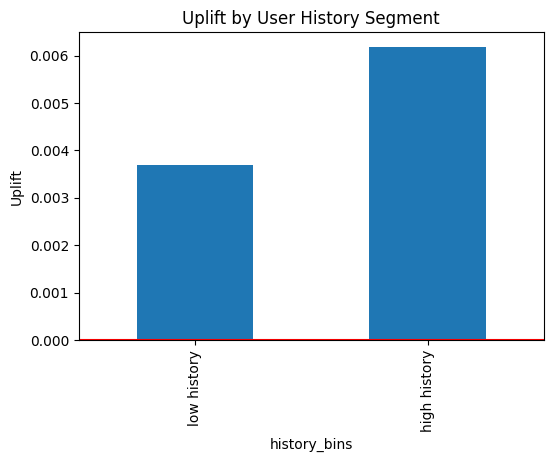

In [18]:
seg['uplift'].plot(
    kind='bar',
    figsize=(6,4),
    title='Uplift by User History Segment'
)
plt.axhline(0, color='red')
plt.ylabel("Uplift")
plt.show()


In [19]:
df_copy['recency_bins']=pd.qcut(
    df_copy['recency'],
    q=2,
    labels=['recent_users','old_users']

)
df_copy.groupby(['recency_bins','treatment'])['outcome'].mean().unstack()

/tmp/ipython-input-4190434324.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_copy.groupby(['recency_bins','treatment'])['outcome'].mean().unstack()


treatment,0,1
recency_bins,,
recent_users,0.007620,0.012182
old_users,0.003186,0.008682


In [20]:
rec_seg=df_copy.groupby(['recency_bins','treatment'])['outcome'].mean().unstack()
rec_seg['uplift']=rec_seg[1]-rec_seg[0]
rec_seg

/tmp/ipython-input-3336043258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rec_seg=df_copy.groupby(['recency_bins','treatment'])['outcome'].mean().unstack()


treatment,0,1,uplift
recency_bins,,,
recent_users,0.007620,0.012182,0.004561
old_users,0.003186,0.008682,0.005496


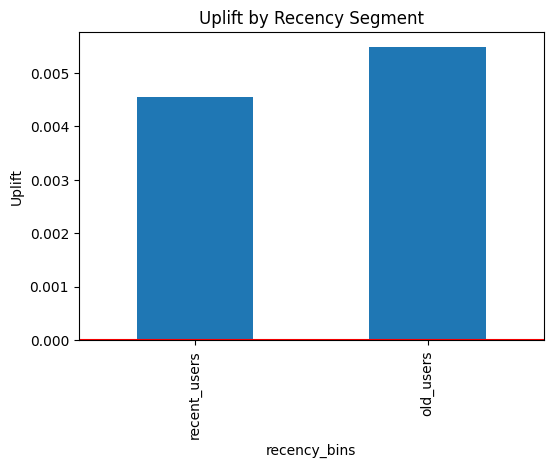

In [21]:
rec_seg['uplift'].plot(
    kind='bar',
    figsize=(6,4),
    title='Uplift by Recency Segment'
)
plt.axhline(0, color='red')
plt.ylabel("Uplift")
plt.show()


In [22]:
X = df_copy[['recency', 'history']]
treatment = df_copy['treatment']
y = df_copy['outcome']


In [23]:
from sklearn.ensemble import RandomForestClassifier
X_control=X[treatment==0]
y_control=y[treatment==0]
X_treat=X[treatment==1]
y_treat=y[treatment==1]

model_c=RandomForestClassifier(n_estimators=200,random_state=42)
model_t=RandomForestClassifier(n_estimators=200,random_state=42)

In [24]:
model_c.fit(X_control, y_control)
model_t.fit(X_treat, y_treat)


RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
p_treat=model_t.predict_proba(X)[:,1]
p_control=model_c.predict_proba(X)[:,1]
df_copy['predict_uplift']=p_treat-p_control



In [33]:
df_copy[['predict_uplift']].describe()

,predict_uplift
count,64000.000000
mean,0.004848
std,0.079417
min,-0.725000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.905000


In [34]:
df_copy.sort_values('predict_uplift',ascending=False).head(10)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment,outcome,history_bins,recency_bins,predict_uplift
8582,10,2) $100 - $200,169.15,0,1,Surburban,1,Web,No E-Mail,0,0,0.00,0,0,high history,old_users,0.905
48937,10,2) $100 - $200,169.19,0,1,Urban,0,Phone,Womens E-Mail,1,1,123.68,1,1,high history,old_users,0.905
16264,10,2) $100 - $200,169.15,0,1,Surburban,0,Web,Womens E-Mail,1,1,104.22,1,1,high history,old_users,0.905
63178,1,1) $0 - $100,78.51,1,0,Urban,1,Web,No E-Mail,0,0,0.00,0,0,low history,recent_users,0.865
10122,4,1) $0 - $100,73.55,0,1,Surburban,1,Web,Womens E-Mail,1,1,225.96,1,1,low history,recent_users,0.865
47118,1,1) $0 - $100,78.52,1,0,Urban,1,Web,No E-Mail,0,0,0.00,0,0,low history,recent_users,0.865
57671,1,1) $0 - $100,72.20,1,0,Surburban,1,Web,Mens E-Mail,1,1,276.67,1,1,low history,recent_users,0.865
3316,1,1) $0 - $100,78.53,1,0,Rural,1,Phone,Womens E-Mail,1,1,163.19,1,1,low history,recent_users,0.865
39486,1,1) $0 - $100,78.55,0,1,Surburban,0,Web,Womens E-Mail,1,1,105.04,1,1,low history,recent_users,0.865
7419,4,1) $0 - $100,73.55,1,0,Urban,0,Web,Mens E-Mail,1,1,85.21,1,1,low history,recent_users,0.865


In [48]:
df_copy['uplift_decile']=pd.qcut(
    df_copy['predict_uplift'],
    10,
    labels=False,
    duplicates='drop'
)

In [49]:
decile_perf = df_copy.groupby('uplift_decile')['outcome'].mean()

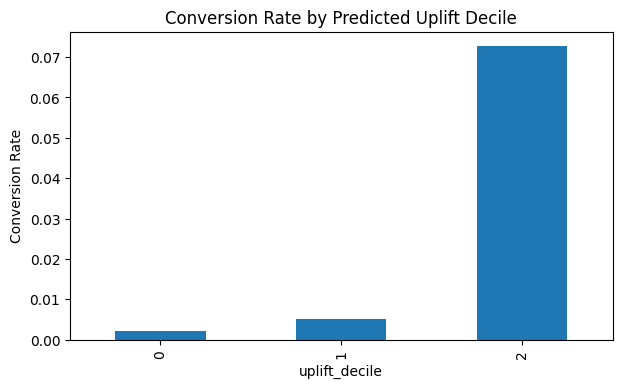

In [50]:
decile_perf.plot(
    kind='bar',
    figsize=(7,4),
    title='Conversion Rate by Predicted Uplift Decile'
)
plt.ylabel("Conversion Rate")
plt.show()

In [51]:
import pickle as pkl
pkl.dump(model_c,open('control_model.pkl','wb'))
pkl.dump(model_t,open('treatment_model.pkl','wb'))

In [52]:
import pickle as pkl

model_c = pkl.load(open('control_model.pkl','rb'))
model_t = pkl.load(open('treatment_model.pkl','rb'))


In [53]:
def predict_uplift_for_users(input_df):
    """
    input_df must contain: recency, history
    """

    X = input_df[['recency', 'history']]

    p_control = model_c.predict_proba(X)[:, 1]
    p_treat   = model_t.predict_proba(X)[:, 1]

    result = input_df.copy()
    result['p_control'] = p_control
    result['p_treatment'] = p_treat
    result['predicted_uplift'] = p_treat - p_control

    return result


In [54]:
new_users = pd.DataFrame({
    'recency': [5, 30, 180],
    'history': [300, 80, 20]
})

predictions = predict_uplift_for_users(new_users)
predictions


,recency,history,p_control,p_treatment,predicted_uplift
0,5,300,0.000000,0.000000,0.00000
1,30,80,0.215000,0.000000,-0.21500
2,180,20,0.008186,0.015106,0.00692


In [55]:
def make_marketing_decision(pred_df, uplift_threshold=0):
    pred_df = pred_df.copy()
    pred_df['send_email'] = pred_df['predicted_uplift'] > uplift_threshold
    return pred_df


In [56]:
final_output = make_marketing_decision(predictions)
final_output


,recency,history,p_control,p_treatment,predicted_uplift,send_email
0,5,300,0.000000,0.000000,0.00000,False
1,30,80,0.215000,0.000000,-0.21500,False
2,180,20,0.008186,0.015106,0.00692,True


In [57]:
predictions['uplift_decile'] = pd.qcut(
    predictions['predicted_uplift'],
    q=10,
    labels=False,
    duplicates='drop'
)

predictions['send_email'] = predictions['uplift_decile'] >= 8
predictions


,recency,history,p_control,p_treatment,predicted_uplift,uplift_decile,send_email
0,5,300,0.000000,0.000000,0.00000,4,False
1,30,80,0.215000,0.000000,-0.21500,0,False
2,180,20,0.008186,0.015106,0.00692,9,True
